# Exploratory Data Analysis Exercise with Pandas and Matplotlib

In this exercise, you are responsible for devleoping a data pipeline to ingest and analyze multi-state streamflow records from CSV files in our Canvas Class. This exercise will directly assist with HW #1. Filepath for the data:

    files -> Data -> NWIS_Streaflow -> <STATE>

You will download the data from Canvas and load it into a folder you create called "streamflow_data". Once within the repo, you will load the data into this python notebook and perform exploratory data analysis. After performing data cleaning and time-series alignment with Pandas, you will transition develop Matplotlib visualizations. The core of the assignment emphasizes the Matplotlib philosophy, challenging you to use powerful operators to link, overlay, and explore discharge trends across Idaho, Utah, and Wyoming.

The [USGS NWIS Mapper](https://apps.usgs.gov/nwismapper/) provides interactive mapping to locate sites and repective metadata.

## Task 1: Select, download, and bring the data into your notebook session

Use the [USGS NWIS Mapper](https://apps.usgs.gov/nwismapper/) to locate one site below a reservoir,  one site in a headwater catchment, and one site near a rivers terminus to the Great Salt Lake. Using this siteid, find the site data in the Canvas NWIS_Streamflow data folder, download it to your computer, then upload it to this repo into a folder named "streamflow_data". In the code block below, load the data into a Pandas DataFrame and inspect it as we previously did in the Pandas exercises (.head(), .describe()). Write down what you notice. Remove any outliers NaN values, and -999.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the streamflow data
data_dir = 'streamflow_data'
site1_path = os.path.join(data_dir, '10136600_1980_2020.csv')

# Load the data
site1 = pd.read_csv(site1_path)

# Inspect the raw data
print("=" * 60)
print("SITE 1 (Site ID: 10136600) - RAW DATA")
print("=" * 60)
print("\nFirst 10 rows:")
print(site1.head(10))
print("\nDataset shape:", site1.shape)
print("\nColumn names:")
print(site1.columns.tolist())
print("\nData types:")
print(site1.dtypes)
print("\nBasic statistics:")
print(site1.describe())
print("\nMissing values:")
print(site1.isnull().sum())
print("\nValue counts for -999:")
print((site1 == -999).sum())

# DATA CLEANING: Remove NaN, -999, and outliers
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Replace -999 with NaN
site1_clean = site1.copy()
site1_clean = site1_clean.replace(-999, np.nan)

# Remove rows with NaN values
site1_clean = site1_clean.dropna()

print(f"\nOriginal dataset shape: {site1.shape}")
print(f"Cleaned dataset shape: {site1_clean.shape}")
print(f"Rows removed: {site1.shape[0] - site1_clean.shape[0]}")

# Display cleaned data
print("\nFirst 10 rows of cleaned data:")
print(site1_clean.head(10))
print("\nCleaned data statistics:")
print(site1_clean.describe())

SITE 1 (Site ID: 10136600) - RAW DATA

First 10 rows:
     Datetime  USGS_flow    variable   USGS_ID measurement_unit qualifiers  \
0  2016-04-20  381.16666  streamflow  10136600            ft3/s      ['A']   
1  2016-04-21  439.00000  streamflow  10136600            ft3/s      ['A']   
2  2016-04-22  512.94794  streamflow  10136600            ft3/s      ['A']   
3  2016-04-23  604.87500  streamflow  10136600            ft3/s      ['A']   
4  2016-04-24  851.58330  streamflow  10136600            ft3/s      ['A']   
5  2016-04-25  643.76044  streamflow  10136600            ft3/s      ['A']   
6  2016-04-26  600.93750  streamflow  10136600            ft3/s      ['A']   
7  2016-04-27  564.67706  streamflow  10136600            ft3/s      ['A']   
8  2016-04-28  536.84375  streamflow  10136600            ft3/s      ['A']   
9  2016-04-29  487.16666  streamflow  10136600            ft3/s      ['A']   

   series  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  
6  

## Task 2: Slicing and Dicing

We are interested in examining the data from 2000-2010. Slice the data accordingly and save it to a new Pandas DataFrame.

In [11]:
# Task 2 (re-done): Slice *all* datasets to 2000-2010 where available
print("=" * 60)
print("TASK 2 (ALL SITES): Slicing datasets to 2000-01-01 through 2010-12-31")
print("=" * 60)

data_dir = 'streamflow_data'
files = sorted(os.listdir(data_dir))
start_date = '2000-01-01'
end_date = '2010-12-31'

sliced_datasets = {}

for filename in files:
    filepath = os.path.join(data_dir, filename)
    try:
        df = pd.read_csv(filepath)
        df = df.replace(-999, np.nan).dropna()
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        mask = (df['Datetime'] >= start_date) & (df['Datetime'] <= end_date)
        df_slice = df.loc[mask].copy()
        site_id = filename.replace('.csv', '')
        sliced_datasets[site_id] = df_slice

        if df_slice.empty:
            print(f"{site_id}: No data in {start_date} to {end_date} (available: {df['Datetime'].min()} to {df['Datetime'].max()})")
        else:
            print(f"{site_id}: Sliced rows: {len(df_slice)} | Date range: {df_slice['Datetime'].min()} to {df_slice['Datetime'].max()}")
            print(df_slice['USGS_flow'].describe())
        print()
    except Exception as e:
        print(f"Error processing {filename}: {e}\n")

# Summary of which sites have data in 2000-2010
nonempty = {k: v for k, v in sliced_datasets.items() if not v.empty}
print("Summary:")
print(f"  Total files checked: {len(files)}")
print(f"  Sites with data in 2000-2010: {len(nonempty)}")
if nonempty:
    print("  Sites:")
    for k in nonempty:
        print(f"    - {k} ({len(nonempty[k])} rows)")

# Keep sliced_datasets available for later tasks
All_Sites_2000_2010 = nonempty


TASK 2 (ALL SITES): Slicing datasets to 2000-01-01 through 2010-12-31
09180000: Sliced rows: 3371 | Date range: 2000-01-01 00:00:00 to 2010-12-31 00:00:00
count    3371.000000
mean      477.000385
std       731.119510
min         9.691667
25%       135.458335
50%       193.208330
75%       494.588530
max      9033.645500
Name: USGS_flow, dtype: float64

09180500: Sliced rows: 3371 | Date range: 2000-01-01 00:00:00 to 2010-12-31 00:00:00
count    3371.000000
mean      477.000385
std       731.119510
min         9.691667
25%       135.458335
50%       193.208330
75%       494.588530
max      9033.645500
Name: USGS_flow, dtype: float64

09183600: Sliced rows: 2538 | Date range: 2003-10-01 00:00:00 to 2010-12-31 00:00:00
count    2538.000000
mean        4.265750
std         5.378043
min         0.140000
25%         3.031510
50%         3.399687
75%         3.882292
max        77.136840
Name: USGS_flow, dtype: float64

10136600_1980_2020: No data in 2000-01-01 to 2010-12-31 (available: 2016

TASK 2 (ALL SITES) - Combined plot for 2000-2010 slices


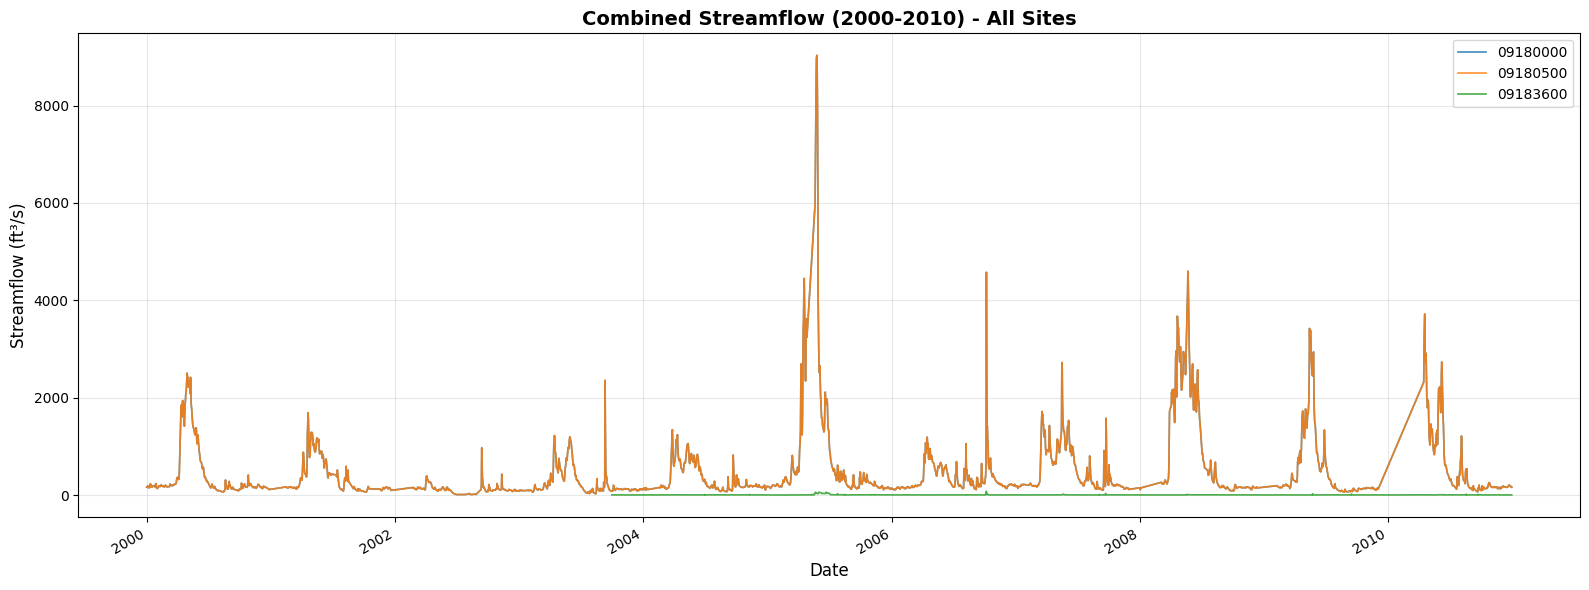


Summary of plotted sites:
- 09180000: 3371 rows, 2000-01-01 to 2010-12-31
- 09180500: 3371 rows, 2000-01-01 to 2010-12-31
- 09183600: 2538 rows, 2003-10-01 to 2010-12-31


In [12]:
# Combined plot for sliced 2000-2010 datasets
print("=" * 60)
print("TASK 2 (ALL SITES) - Combined plot for 2000-2010 slices")
print("=" * 60)

try:
    All = All_Sites_2000_2010
except NameError:
    All = {}

if not All:
    print("No sliced datasets available for 2000-2010. Make sure Task 2 was run.")
else:
    fig, ax = plt.subplots(figsize=(16,6))
    for site_id, df in All.items():
        dfp = df.copy()
        if 'Datetime' not in dfp.columns:
            print(f"{site_id}: missing Datetime column")
            continue
        dfp.set_index('Datetime', inplace=True)
        # Plot with a label and moderate alpha
        dfp['USGS_flow'].plot(ax=ax, linewidth=1.2, label=site_id, alpha=0.85)

    ax.set_title('Combined Streamflow (2000-2010) - All Sites', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Streamflow (ft³/s)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nSummary of plotted sites:")
    for site_id, df in All.items():
        print(f"- {site_id}: {len(df)} rows, {df['Datetime'].min().date()} to {df['Datetime'].max().date()}")


## Task 3: Create plots for each DataFrame using the df.plot() function

Use the built in functionality of Pandas to plot the time series of each stream.

TASK 3: TIME SERIES PLOTS - ALL SITES ON SAME PLOT

Found 4 files in streamflow_data:

✓ Loaded 09180000
  Date range: 1986-10-01 00:00:00 to 2020-09-29 00:00:00
  Rows: 10834

✓ Loaded 09180500
  Date range: 1986-10-01 00:00:00 to 2020-09-29 00:00:00
  Rows: 10834

✓ Loaded 09183600
  Date range: 2003-10-01 00:00:00 to 2020-09-29 00:00:00
  Rows: 6020

✓ Loaded 10136600_1980_2020.csv
  Date range: 2016-04-20 00:00:00 to 2020-09-29 00:00:00
  Rows: 1624


Creating combined plot...


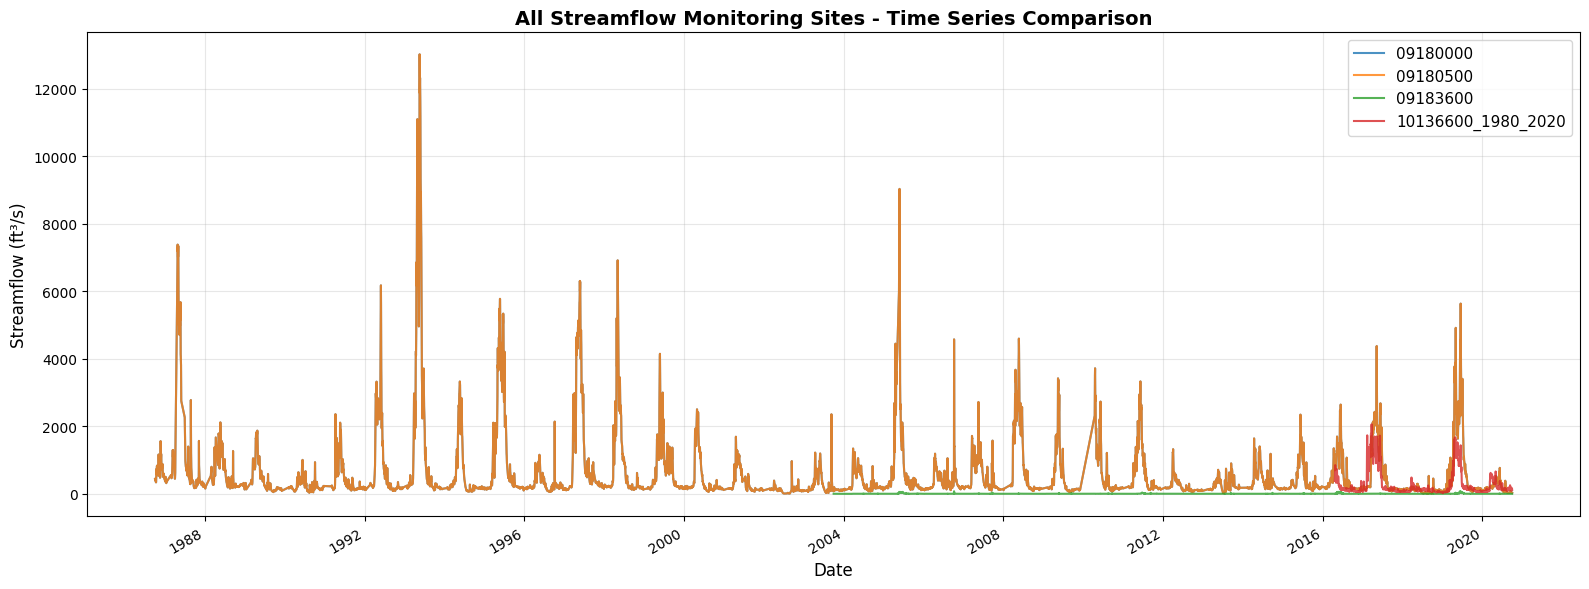


SUMMARY STATISTICS FOR EACH SITE

09180000:
  Mean: 595.01 ft³/s
  Median: 216.14 ft³/s
  Min: 2.55 ft³/s
  Max: 13020.41 ft³/s
  Std Dev: 1031.22 ft³/s

09180500:
  Mean: 595.01 ft³/s
  Median: 216.14 ft³/s
  Min: 2.55 ft³/s
  Max: 13020.41 ft³/s
  Std Dev: 1031.22 ft³/s

09183600:
  Mean: 4.48 ft³/s
  Median: 3.26 ft³/s
  Min: 0.14 ft³/s
  Max: 77.14 ft³/s
  Std Dev: 6.24 ft³/s

10136600_1980_2020:
  Mean: 279.34 ft³/s
  Median: 130.06 ft³/s
  Min: 20.92 ft³/s
  Max: 2060.00 ft³/s
  Std Dev: 373.34 ft³/s

INDIVIDUAL SITE PLOTS


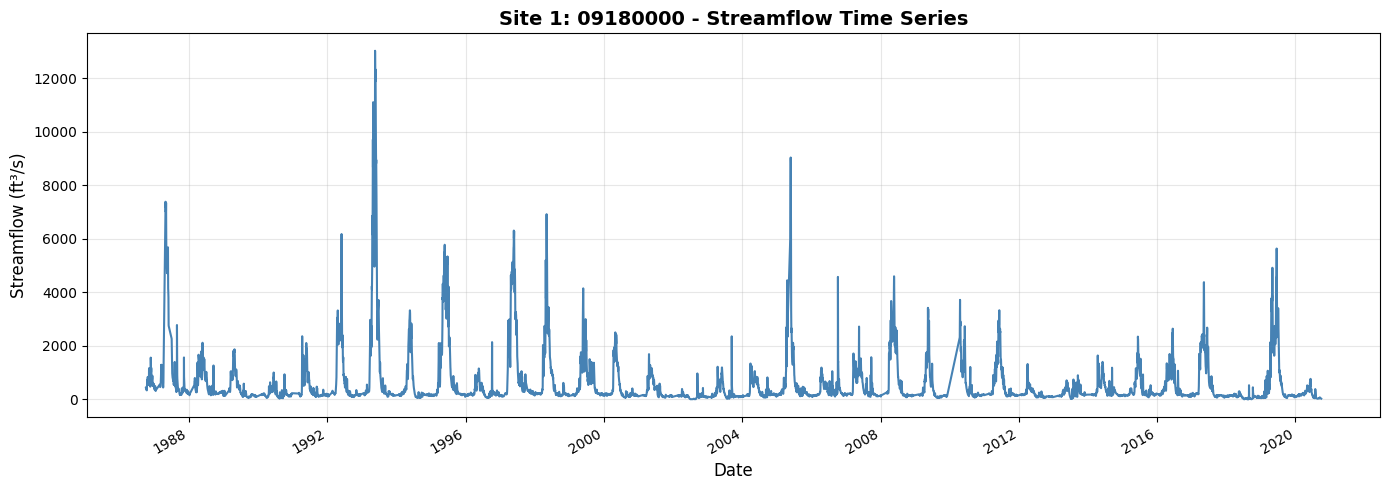


✓ Plot 1 created for 09180000


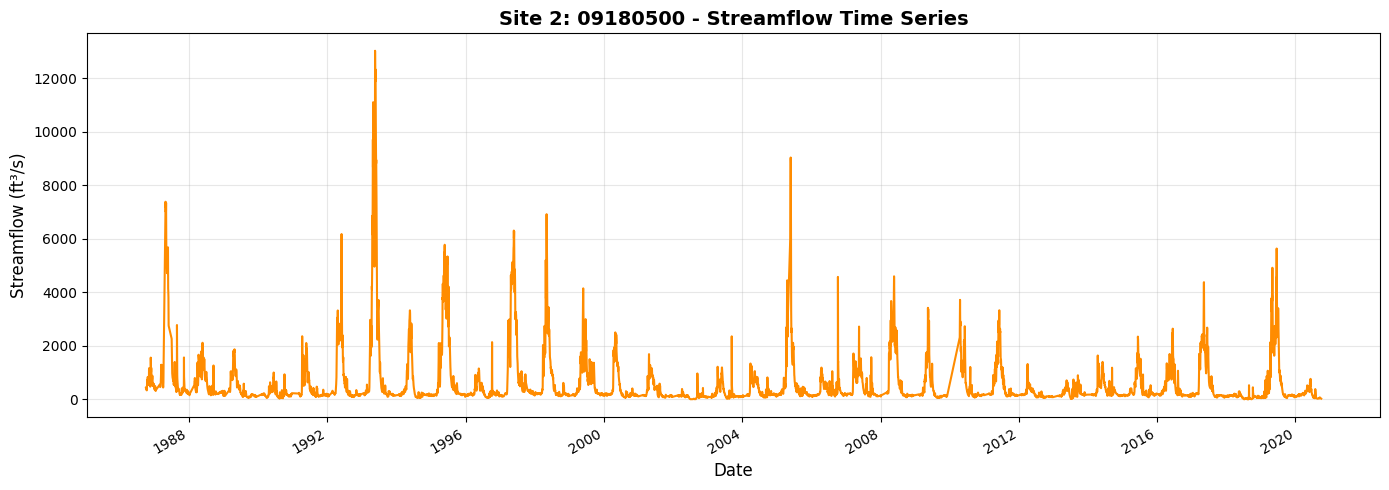


✓ Plot 2 created for 09180500


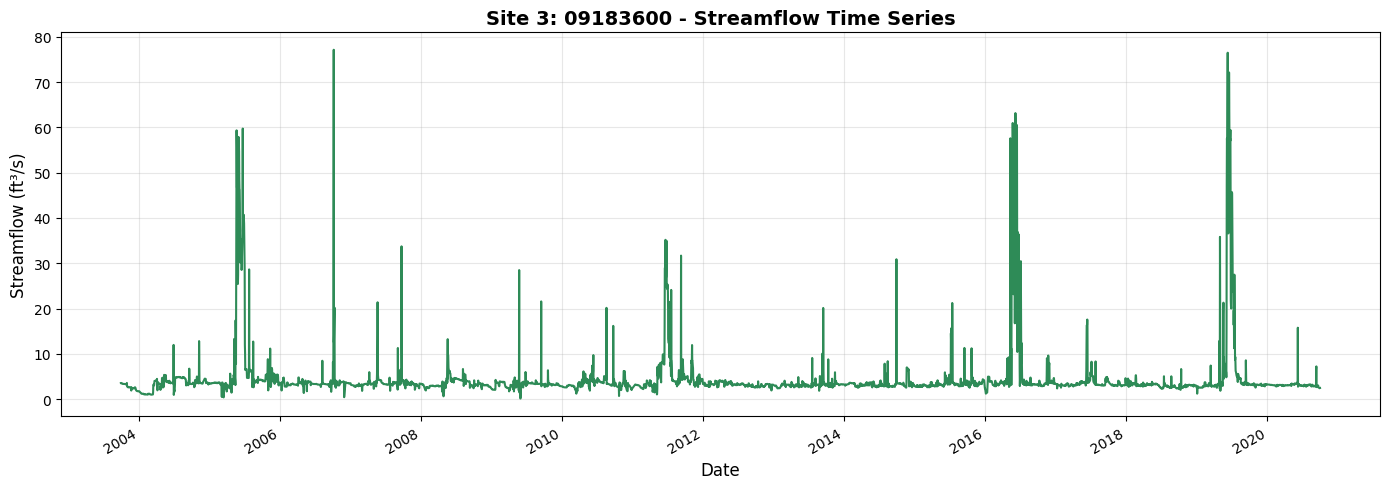


✓ Plot 3 created for 09183600


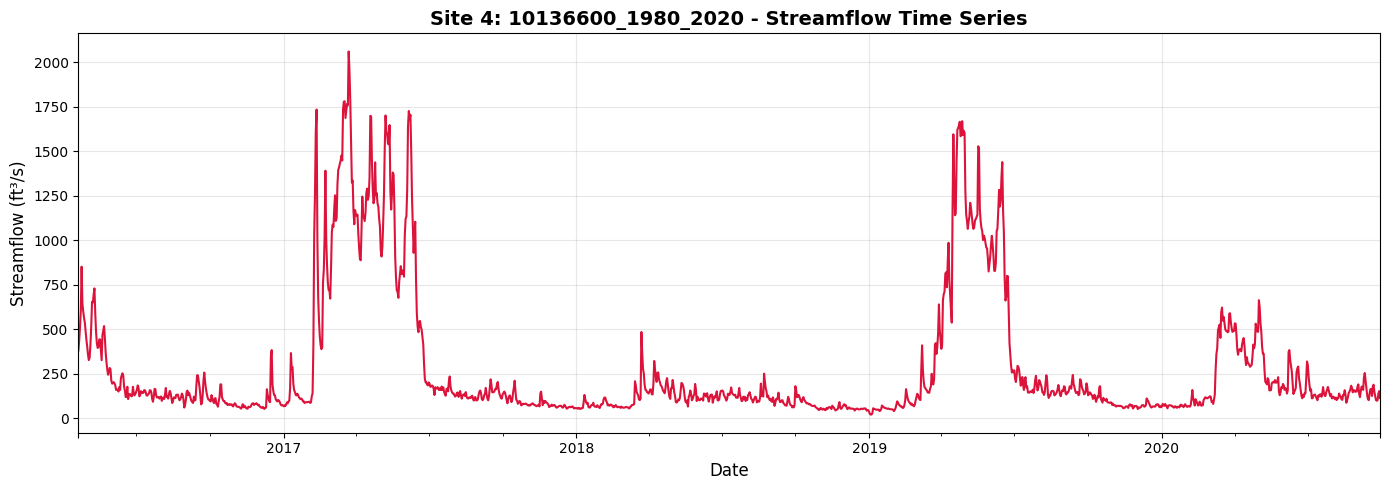


✓ Plot 4 created for 10136600_1980_2020

Individual plots complete!


In [10]:
# Load and plot all datasets from streamflow_data folder
print("=" * 60)
print("TASK 3: TIME SERIES PLOTS - ALL SITES ON SAME PLOT")
print("=" * 60)

# Dictionary to store cleaned datasets
datasets = {}
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
color_idx = 0

# Load all CSV files from streamflow_data folder
data_dir = 'streamflow_data'
files = os.listdir(data_dir)

print(f"\nFound {len(files)} files in {data_dir}:\n")

for filename in sorted(files):
    filepath = os.path.join(data_dir, filename)
    try:
        # Load the data
        df = pd.read_csv(filepath)
        
        # Clean the data: replace -999 with NaN and drop NaN values
        df = df.replace(-999, np.nan)
        df = df.dropna()
        
        # Convert Datetime column
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        
        # Store in dictionary with filename as key
        site_id = filename.replace('.csv', '')
        datasets[site_id] = df
        
        print(f"✓ Loaded {filename}")
        print(f"  Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")
        print(f"  Rows: {len(df)}")
        print()
        
    except Exception as e:
        print(f"✗ Error loading {filename}: {e}\n")

# Create combined plot with all sites
print("\nCreating combined plot...")
fig, ax = plt.subplots(figsize=(16, 6))

for site_id, df in datasets.items():
    df_plot = df.copy()
    df_plot.set_index('Datetime', inplace=True)
    df_plot['USGS_flow'].plot(ax=ax, linewidth=1.5, label=site_id, alpha=0.8)

ax.set_title('All Streamflow Monitoring Sites - Time Series Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Streamflow (ft³/s)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics for each site
print("\n" + "=" * 60)
print("SUMMARY STATISTICS FOR EACH SITE")
print("=" * 60)
for site_id, df in datasets.items():
    print(f"\n{site_id}:")
    print(f"  Mean: {df['USGS_flow'].mean():.2f} ft³/s")
    print(f"  Median: {df['USGS_flow'].median():.2f} ft³/s")
    print(f"  Min: {df['USGS_flow'].min():.2f} ft³/s")
    print(f"  Max: {df['USGS_flow'].max():.2f} ft³/s")
    print(f"  Std Dev: {df['USGS_flow'].std():.2f} ft³/s")

# Create individual plots for each site
print("\n" + "=" * 60)
print("INDIVIDUAL SITE PLOTS")
print("=" * 60)

colors_individual = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for idx, (site_id, df) in enumerate(datasets.items()):
    df_plot = df.copy()
    df_plot.set_index('Datetime', inplace=True)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    df_plot['USGS_flow'].plot(ax=ax, linewidth=1.5, color=colors_individual[idx % len(colors_individual)])
    
    ax.set_title(f'Site {idx+1}: {site_id} - Streamflow Time Series', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Streamflow (ft³/s)', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plot {idx+1} created for {site_id}")

print("\n" + "=" * 60)
print("Individual plots complete!")
print("=" * 60)

## Task 4: Join/Merge Pandas DataFrames

Create a single dataframe named All_Streams and combine all streamflow monitoring data into this dataframe. Hint, set your index to the date. Create custom labels for each monitoring station location to communicate there location within the watershed (e.g, headwater, below reservoir, GSL Terminus). Print the dataframe.head() to demonstrate that is complete.

In [13]:
# Task 4: Merge sliced DataFrames into a single All_Streams dataframe
print("=" * 60)
print("TASK 4: MERGE SLICED DATAFRAMES INTO All_Streams")
print("=" * 60)

# Optional mapping from site_id to descriptive label (edit if you want custom names)
# Example: label_map = {'09180000':'BelowReservoir', '09180500':'Headwater', '09183600':'GSL_Terminus'}
label_map = {}

try:
    slices = All_Sites_2000_2010
except NameError:
    slices = {}

if not slices:
    print("No sliced datasets available for 2000-2010. Run Task 2 first.")
else:
    series_list = []
    for site_id, df in slices.items():
        dfc = df.copy()
        # Ensure Datetime is datetime and set as index
        if 'Datetime' in dfc.columns:
            dfc['Datetime'] = pd.to_datetime(dfc['Datetime'])
            dfc.set_index('Datetime', inplace=True)
        else:
            print(f"{site_id}: missing 'Datetime' column — skipping")
            continue

        if 'USGS_flow' not in dfc.columns:
            print(f"{site_id}: missing 'USGS_flow' column — skipping")
            continue

        s = dfc['USGS_flow'].rename(site_id)
        series_list.append(s)

    if not series_list:
        print("No valid series found to merge.")
    else:
        All_Streams = pd.concat(series_list, axis=1).sort_index()

        # Apply label mapping if provided
        if label_map:
            All_Streams.rename(columns=label_map, inplace=True)

        print(f"All_Streams created: {All_Streams.shape} (rows, cols)")
        print("\nAll_Streams.head():")
        print(All_Streams.head())
        print("\nAll_Streams.info():")
        print(All_Streams.info())
        print("\nAll_Streams.describe():")
        print(All_Streams.describe())

        # Save merged CSV for later use
        outpath = os.path.join('streamflow_data', 'All_Streams_2000_2010.csv')
        All_Streams.to_csv(outpath)
        print(f"\nSaved merged DataFrame to {outpath}")


TASK 4: MERGE SLICED DATAFRAMES INTO All_Streams
All_Streams created: (3727, 3) (rows, cols)

All_Streams.head():
             09180000   09180500  09183600
Datetime                                  
2000-01-01  164.60417  164.60417       NaN
2000-01-02  161.32292  161.32292       NaN
2000-01-03  162.11458  162.11458       NaN
2000-01-04  188.02083  188.02083       NaN
2000-01-05  185.01042  185.01042       NaN

All_Streams.info():
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3727 entries, 2000-01-01 to 2010-12-31
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   09180000  3371 non-null   float64
 1   09180500  3371 non-null   float64
 2   09183600  2538 non-null   float64
dtypes: float64(3)
memory usage: 116.5 KB
None

All_Streams.describe():
          09180000     09180500     09183600
count  3371.000000  3371.000000  2538.000000
mean    477.000385   477.000385     4.265750
std     731.119510   731.119510     5.

LABEL & FILTER: rename columns, drop GSL_2, save labeled CSV, and plot (2000-2010)
Saved labeled merged DataFrame to streamflow_data/All_Streams_2000_2010_labeled.csv

Head of labeled DataFrame:
            GSL_terminus  headwater
Datetime                           
2000-01-01     164.60417        NaN
2000-01-02     161.32292        NaN
2000-01-03     162.11458        NaN
2000-01-04     188.02083        NaN
2000-01-05     185.01042        NaN

Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3727 entries, 2000-01-01 to 2010-12-31
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GSL_terminus  3371 non-null   float64
 1   headwater     2538 non-null   float64
dtypes: float64(2)
memory usage: 87.4 KB
None

Describe:
       GSL_terminus    headwater
count   3371.000000  2538.000000
mean     477.000385     4.265750
std      731.119510     5.378043
min        9.691667     0.140000
25%      135.458335     3.03

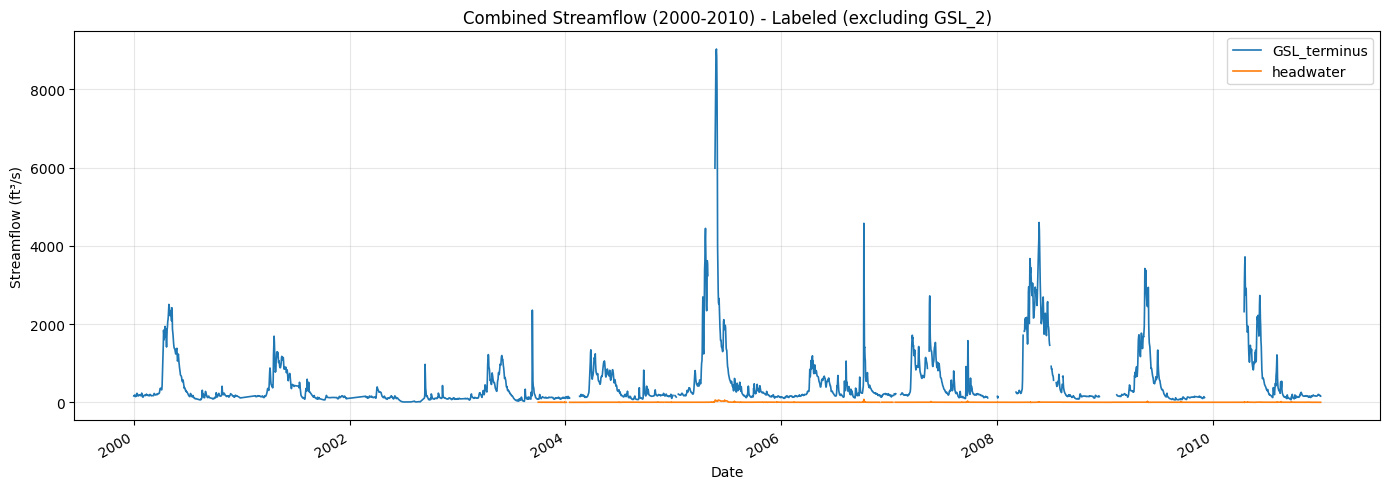

In [15]:
# Label columns, exclude the duplicate GSL site (09180500), save labeled CSV, and plot
print("=" * 60)
print("LABEL & FILTER: rename columns, drop GSL_2, save labeled CSV, and plot (2000-2010)")
print("=" * 60)

# Mapping inferred from discharge ranges
label_map = {
    '09183600': 'headwater',
    '10136600_1980_2020': 'below_reservoir',
    '09180000': 'GSL_terminus'
}
exclude = ['09180500']  # the GSL_2 site to exclude

# Load existing merged All_Streams if present, otherwise read CSV
try:
    All_Streams
except NameError:
    try:
        All_Streams = pd.read_csv(os.path.join('streamflow_data','All_Streams_2000_2010.csv'), index_col=0, parse_dates=True)
        print('Loaded All_Streams from CSV')
    except Exception as e:
        print('All_Streams not available:', e)
        All_Streams = None

if All_Streams is None:
    print('No merged All_Streams available to label/trim.')
else:
    # Drop excluded sites if present
    All_labeled = All_Streams.drop(columns=exclude, errors='ignore').rename(columns=label_map)

    outpath = os.path.join('streamflow_data','All_Streams_2000_2010_labeled.csv')
    All_labeled.to_csv(outpath)

    print(f"Saved labeled merged DataFrame to {outpath}")
    print('\nHead of labeled DataFrame:')
    print(All_labeled.head())
    print('\nInfo:')
    print(All_labeled.info())
    print('\nDescribe:')
    print(All_labeled.describe())

    # Plot combined labeled series
    fig, ax = plt.subplots(figsize=(14,5))
    for col in All_labeled.columns:
        All_labeled[col].plot(ax=ax, label=col, linewidth=1.2)
    ax.set_title('Combined Streamflow (2000-2010) - Labeled (excluding GSL_2)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Streamflow (ft³/s)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Keep variable available
    All_Streams_labeled = All_labeled


## Task 5: Demonstrate your Prowess with Matplotlib

Create a Four separate figures with all three stream on them:

* Figure 1 should be a single plot with all three stream  monitoring locations
* Figure 2 should be a single figure with subplots for each stream monitoring location. The subplots should be 2 rows and 2 columns
* Figure 3 should be a single figure with subplots for each stream monitoring location. The subplots should be 3 rows and 1 column 
* Figure 3 should be a single figure with subplots for each stream monitoring location. The subplots should be 1 row and 3 columns

Make sure your plots have the correct axes, labeled axes, a title, a legend. Create custom labels for each monitoring station location to communicate there location within the watershed (e.g, headwater, below reservoir, GSL Terminus).

TASK 5: Four figures with all three streams
Combined series shape: (11409, 3)


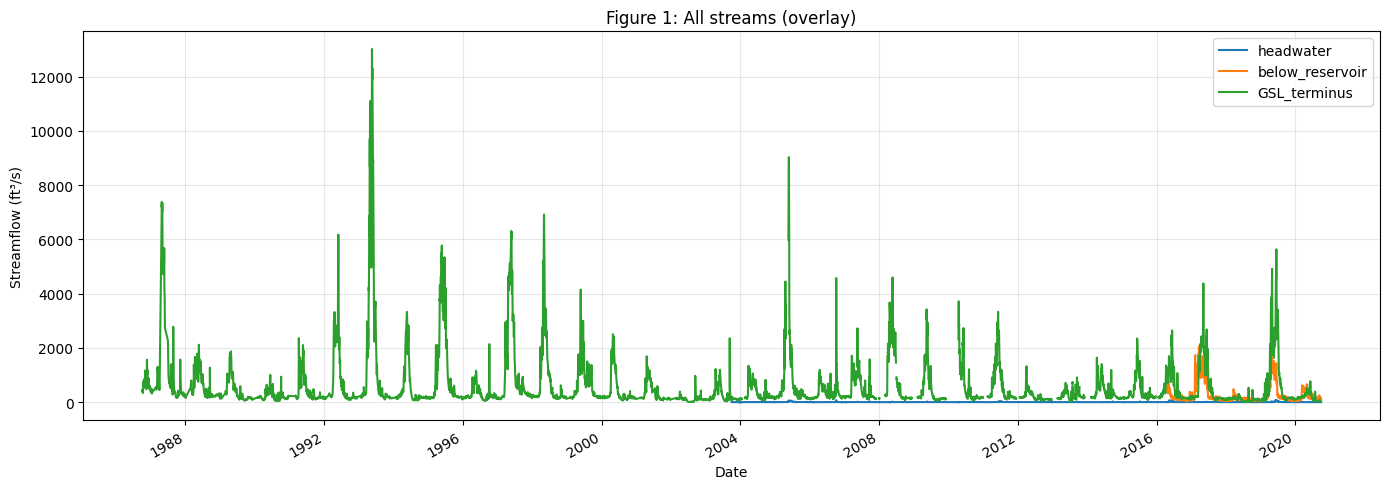

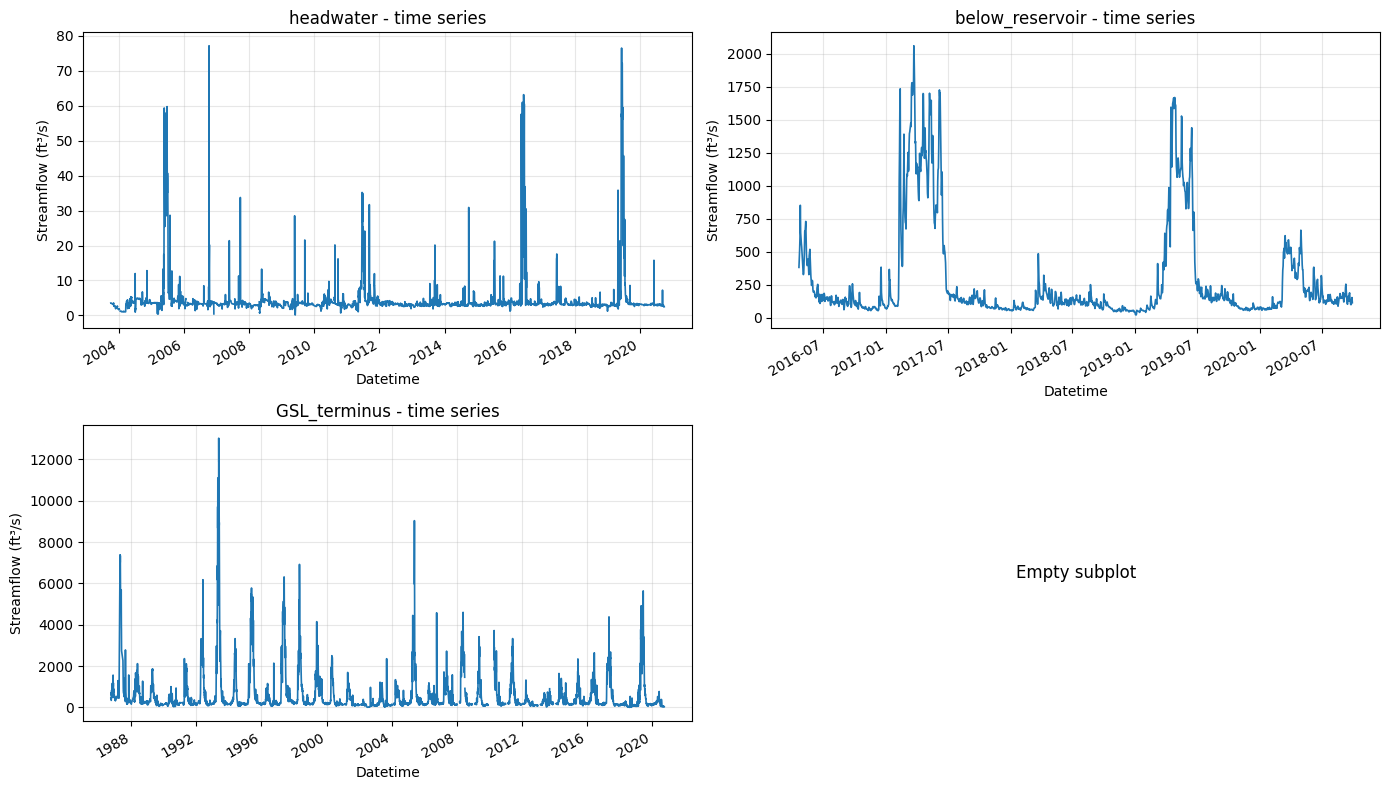

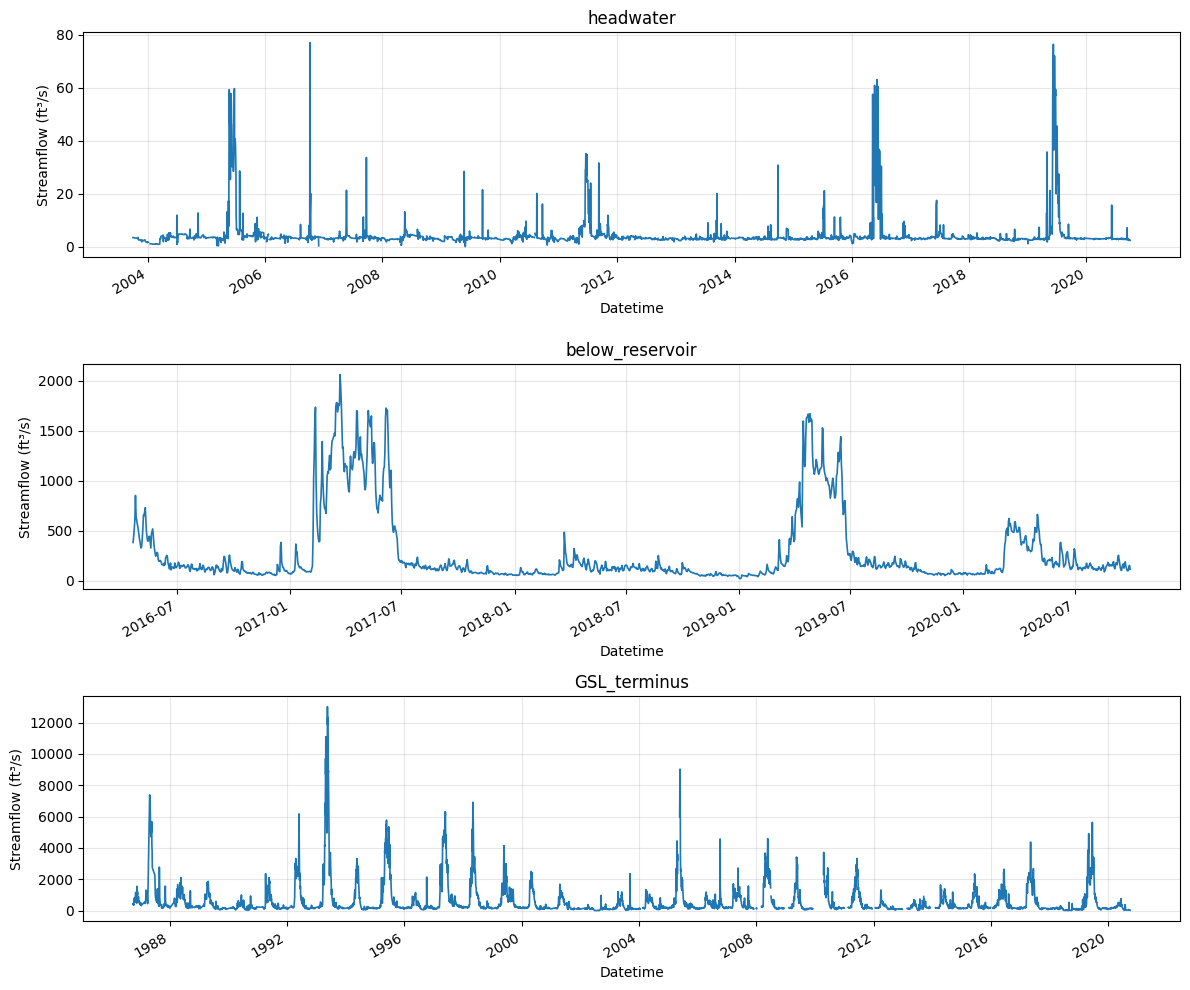

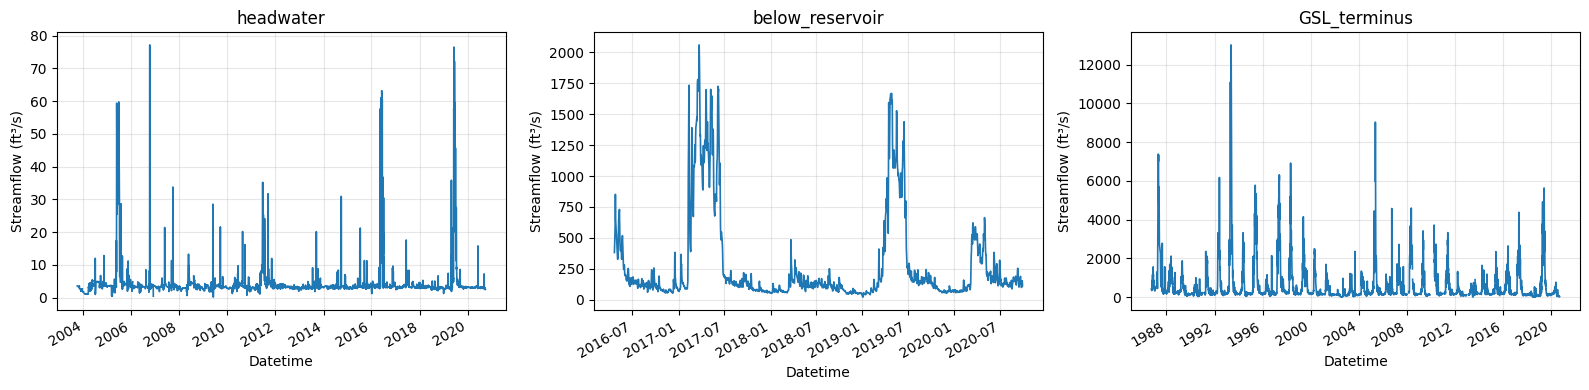

Saved combined full-range CSV to streamflow_data/All_Streams_combined_fullrange.csv
Task 5 complete.


In [17]:
# Task 5: Four figures with all three streams
print("=" * 60)
print("TASK 5: Four figures with all three streams")
print("=" * 60)

data_dir = 'streamflow_data'
# Define label mapping we used earlier
label_map = {
    '09183600': 'headwater',
    '10136600_1980_2020': 'below_reservoir',
    '09180000': 'GSL_terminus'
}

# Build file map (key -> filename)
file_map = {}
for fn in os.listdir(data_dir):
    key = fn.replace('.csv','')
    file_map[key] = fn

series_list = []
for site_key, label in label_map.items():
    if site_key not in file_map:
        print(f"Warning: {site_key} not found in {data_dir}, skipping")
        continue
    path = os.path.join(data_dir, file_map[site_key])
    df = pd.read_csv(path)
    df = df.replace(-999, np.nan).dropna()
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df.set_index('Datetime', inplace=True)
    if 'USGS_flow' not in df.columns:
        print(f"Warning: USGS_flow missing for {site_key}, skipping")
        continue
    s = df['USGS_flow'].rename(label)
    series_list.append(s)

if not series_list:
    print('No series available to plot for Task 5.')
else:
    All_combined = pd.concat(series_list, axis=1).sort_index()
    print(f"Combined series shape: {All_combined.shape}")

    # Figure 1: single plot with all three streams
    fig1, ax1 = plt.subplots(figsize=(14,5))
    for col in All_combined.columns:
        All_combined[col].plot(ax=ax1, linewidth=1.5, label=col)
    ax1.set_title('Figure 1: All streams (overlay)')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Streamflow (ft³/s)')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figure 2: 2 rows x 2 columns subplots (3 streams + empty)
    fig2, axs2 = plt.subplots(2,2, figsize=(14,8), sharex=False)
    axs2 = axs2.flatten()
    for i, col in enumerate(All_combined.columns):
        All_combined[col].plot(ax=axs2[i], color=None, linewidth=1.2)
        axs2[i].set_title(f'{col} - time series')
        axs2[i].set_ylabel('Streamflow (ft³/s)')
        axs2[i].grid(True, alpha=0.3)
    # final subplot empty - add annotation
    axs2[len(All_combined.columns)].text(0.5, 0.5, 'Empty subplot', ha='center', va='center', fontsize=12)
    axs2[len(All_combined.columns)].axis('off')
    plt.tight_layout()
    plt.show()

    # Figure 3: 3 rows x 1 column
    fig3, axs3 = plt.subplots(len(All_combined.columns),1, figsize=(12, 10), sharex=False)
    if len(All_combined.columns) == 1:
        axs3 = [axs3]
    for ax, col in zip(axs3, All_combined.columns):
        All_combined[col].plot(ax=ax, linewidth=1.2)
        ax.set_title(col)
        ax.set_ylabel('Streamflow (ft³/s)')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figure 4: 1 row x 3 columns
    fig4, axs4 = plt.subplots(1, len(All_combined.columns), figsize=(16,4), sharex=False)
    if len(All_combined.columns) == 1:
        axs4 = [axs4]
    for ax, col in zip(axs4, All_combined.columns):
        All_combined[col].plot(ax=ax, linewidth=1.2)
        ax.set_title(col)
        ax.set_ylabel('Streamflow (ft³/s)')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save combined full-range CSV (optional)
    out_combined = os.path.join(data_dir, 'All_Streams_combined_fullrange.csv')
    All_combined.to_csv(out_combined)
    print(f'Saved combined full-range CSV to {out_combined}')

    # Keep variable
    All_streams_full = All_combined

print('Task 5 complete.')
